<h1 style="color:#1976D2;">Decoding Tamil Nadu 2026 Assembly elections</h1>

### Project Introduction

The Tamil Nadu Assembly Election 2026 was one of the most closely watched state elections in India, marked by major regional shifts, emerging political players, and constituency-level transitions. 

This project analyzes and compares the 2021 and 2026 Tamil Nadu Assembly election results using publicly available Election Commission of India (ECI) data.

The objective of this analysis is not to explain *why* parties won or lost, but to identify and present the most significant electoral patterns through clear, neutral, and data-driven storytelling.

The analysis focuses on:
- Region-wise political shifts
- Constituency-level party transitions
- Electoral competitiveness through victory margins

The project was developed as part of the **Resume Project Challenge (RPC)** by Codebasics, designed to test storytelling-first data analytics skills.

### Objective

The primary objective of this project is to uncover and communicate the most important stories hidden within the 2026 Tamil Nadu Assembly election results using data analysis and visualization techniques.

This project aims to:

- Compare the 2021 and 2026 Tamil Nadu Assembly election results
- Identify major regional political shifts across the six editorial regions
- Analyze constituencies that changed winning parties between elections
- Examine electoral competitiveness using victory margins
- Build clear and engaging visualizations for storytelling
- Present insights in a neutral, factual, and non-partisan manner

The analysis relies entirely on publicly available Election Commission of India (ECI) data and does not use opinion polls, exit polls, or demographic assumptions.

In [1]:
import pandas as pd
import numpy as np

In [2]:
tn_2021 = pd.read_csv("data/tn_2021_results.csv")
tn_2026 = pd.read_csv("data/tn_2026_results.csv")
constituency_master = pd.read_csv("data/constituency_master.csv")

In [3]:
tn_2021.shape

(4232, 8)

In [4]:
tn_2026.shape

(4257, 8)

In [5]:
constituency_master.shape

(234, 5)

In [6]:
tn_2021.head()

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipundi,1,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro
1,Gummidipundi,1,PRAKASH M,PMK,75514,78.08,GEN,Chennai Metro
2,Gummidipundi,1,USHA,NTK,11701,78.08,GEN,Chennai Metro
3,Gummidipundi,1,DILLIY K.M,DMDK,2576,78.08,GEN,Chennai Metro
4,Gummidipundi,1,None Of The Above,NOTA,1783,78.08,GEN,Chennai Metro


In [7]:
tn_2026.head()

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipoondi,1,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro
1,Gummidipoondi,1,SUDHAKAR.V,AIADMK,66375,NaN,GEN,Chennai Metro
2,Gummidipoondi,1,T.J.GOVINDARAJAN,DMK,62492,NaN,GEN,Chennai Metro
3,Gummidipoondi,1,"R.SRIDAR. B.L.,",NTK,4756,NaN,GEN,Chennai Metro
4,Gummidipoondi,1,NOTA,NOTA,937,NaN,GEN,Chennai Metro


In [8]:
list(tn_2021.columns)

['constituency',
 'ac_number',
 'candidate',
 'party',
 'votes',
 'turnout',
 'reserved',
 'region']

In [9]:
list(tn_2026.columns)

['constituency',
 'ac_number',
 'candidate',
 'party',
 'votes',
 'turnout',
 'reserved',
 'region']

In [10]:
tn_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4232 entries, 0 to 4231
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   constituency  4232 non-null   object 
 1   ac_number     4232 non-null   int64  
 2   candidate     4232 non-null   object 
 3   party         4232 non-null   object 
 4   votes         4232 non-null   int64  
 5   turnout       4232 non-null   float64
 6   reserved      4232 non-null   object 
 7   region        4232 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 264.6+ KB


In [11]:
tn_2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   constituency  4257 non-null   object 
 1   ac_number     4257 non-null   int64  
 2   candidate     4257 non-null   object 
 3   party         4257 non-null   object 
 4   votes         4257 non-null   int64  
 5   turnout       0 non-null      float64
 6   reserved      4257 non-null   object 
 7   region        4257 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 266.2+ KB


In [12]:
tn_2021.isnull().sum()

constituency    0
ac_number       0
candidate       0
party           0
votes           0
turnout         0
reserved        0
region          0
dtype: int64

In [13]:
tn_2026.isnull().sum()

constituency       0
ac_number          0
candidate          0
party              0
votes              0
turnout         4257
reserved           0
region             0
dtype: int64

* Turnout missing in 2026. That’s expected.

In [14]:
tn_2021['party'].value_counts()

party
IND                                          2073
NOTA                                          234
NTK                                           234
AIADMK                                        191
DMK                                           188
                                             ... 
South India Forward Bloc                        1
Universal Brotherhood Movement                  1
Anaithu Ulaga Tamilargal Munnetra Kalagam       1
Ulaga Makkal Katchi                             1
Tamilnadu Mahatma Gandhi Makkal Katchi          1
Name: count, Length: 109, dtype: int64

In [15]:
tn_2026['party'].value_counts()

party
IND                           2209
NTK                            234
NOTA                           234
TVK                            233
DMK                            176
                              ... 
Republican Party of India        1
Bharatha Makkal Katchi           1
Kamarajar Deseeya Congress       1
Rashtriya Janata Dal             1
Indian Christian Front           1
Name: count, Length: 105, dtype: int64

In [16]:
tn_2021['region'].value_counts()

region
South            1072
Central           749
Chennai Metro     712
Kongu             622
North             567
Delta             510
Name: count, dtype: int64

In [17]:
tn_2026['region'].value_counts()

region
South            1001
Central           747
Chennai Metro     727
Kongu             634
North             621
Delta             527
Name: count, dtype: int64

In [18]:
tn_2021['reserved'].value_counts()

reserved
GEN    3575
SC      627
ST       30
Name: count, dtype: int64

In [19]:
tn_2026['reserved'].value_counts()

reserved
GEN    3599
SC      631
ST       27
Name: count, dtype: int64

In [20]:
tn_2021['ac_number'].nunique()

234

In [21]:
tn_2026['ac_number'].nunique()

234

In [22]:
tn_2021.duplicated().sum()

np.int64(0)

In [23]:
tn_2026.duplicated().sum()

np.int64(0)

* No Duplicates records found

In [24]:
# Remove Extra Spaces From Column Names
tn_2021.columns = tn_2021.columns.str.strip()
tn_2026.columns = tn_2026.columns.str.strip()
constituency_master.columns = constituency_master.columns.str.strip()

In [25]:
# Remove Extra Spaces From Text Columns
text_cols = ['constituency', 'candidate', 'party', 'reserved', 'region']

for col in text_cols:
    tn_2021[col] = tn_2021[col].str.strip()
    tn_2026[col] = tn_2026[col].str.strip()

In [26]:
sorted(tn_2026['party'].unique())

['AIADMK',
 "ALL PENSIONER'S PARTY",
 'AMMK',
 'Aanaithinthiya Jananayaka Pathukappu Kazhagam',
 'Ahila India Dhayaga Makkal Munnetra Katchi',
 'Ahimsa Socialist Party',
 'Akila Inthiya Makkal Marumalarchi Kazhakam',
 'All India Forward Bloc',
 'All India Jananayaka Makkal Kazhagam',
 'All India Majlis-E-Inquilab-E-Millat',
 'All India Puratchi Thalaivar Makkal Munnettra Kazhagam',
 'All India Uzhavargal Uzhaippalargal Katchi',
 'All India Youth Development Party',
 'Anaithindia Samudaya Munnetra Kazhagam',
 'Anaithinthiya Anna Dravida Makkal Seyal katchi',
 'Anna MGR Dravida Makkal Kalgam',
 'Anna Makkal Katchi',
 'Anna Puratchi Thalaivar Amma Dravida Munnetra Kazhagam',
 'Anti Corruption Dynamic Party',
 'BJP',
 'Bahujan Dravida Party',
 'Bahujan Samaj Party',
 'Bharat Jan Chikitsa Party',
 'Bharatha Makkal Katchi',
 'CPI',
 'CPI(M)',
 'Communist Party of India (Marxist-Leninist) (Liberation)',
 'Communist Party of India (Marxist-Leninist) Red Star',
 'DMDK',
 'DMK',
 'Democratic Nat

Sort Constituency Candidates by Votes

In [28]:
tn_2021_sorted = tn_2021.sort_values(
    by=['ac_number', 'votes'],
    ascending=[True, False]
)

In [29]:
tn_2026_sorted = tn_2026.sort_values(
    by=['ac_number', 'votes'],
    ascending=[True, False]
)

In [30]:
winners_2021 = tn_2021_sorted.groupby('ac_number').first().reset_index()

In [31]:
winners_2026 = tn_2026_sorted.groupby('ac_number').first().reset_index()

In [32]:
runnerup_2021 = tn_2021_sorted.groupby('ac_number').nth(1).reset_index()

In [33]:
runnerup_2026 = tn_2026_sorted.groupby('ac_number').nth(1).reset_index()

In [34]:
winners_2021 = winners_2021.rename(columns={
    'candidate': 'winner_candidate',
    'party': 'winner_party',
    'votes': 'winner_votes'
})

In [35]:
winners_2026 = winners_2026.rename(columns={
    'candidate': 'winner_candidate',
    'party': 'winner_party',
    'votes': 'winner_votes'
})

In [36]:
winner_table_2021 = winners_2021.merge(
    runnerup_2021[['ac_number', 'candidate', 'party', 'votes']],
    on='ac_number',
    suffixes=('', '_runnerup')
)

winner_table_2026 = winners_2026.merge(
    runnerup_2026[['ac_number', 'candidate', 'party', 'votes']],
    on='ac_number',
    suffixes=('', '_runnerup')
)

In [37]:
winner_table_2021 = winner_table_2021.rename(columns={
    'candidate': 'runnerup_candidate',
    'party': 'runnerup_party',
    'votes': 'runnerup_votes'
})

winner_table_2026 = winner_table_2026.rename(columns={
    'candidate': 'runnerup_candidate',
    'party': 'runnerup_party',
    'votes': 'runnerup_votes'
})

In [38]:
winner_table_2021['margin'] = (
    winner_table_2021['winner_votes']
    - winner_table_2021['runnerup_votes']
)

winner_table_2026['margin'] = (
    winner_table_2026['winner_votes']
    - winner_table_2026['runnerup_votes']
)

In [39]:
total_votes_2021 = tn_2021.groupby('ac_number')['votes'].sum().reset_index()

total_votes_2026 = tn_2026.groupby('ac_number')['votes'].sum().reset_index()

In [40]:
total_votes_2021 = total_votes_2021.rename(columns={
    'votes': 'total_votes'
})

total_votes_2026 = total_votes_2026.rename(columns={
    'votes': 'total_votes'
})

In [41]:
winner_table_2021 = winner_table_2021.merge(
    total_votes_2021,
    on='ac_number'
)

winner_table_2026 = winner_table_2026.merge(
    total_votes_2026,
    on='ac_number'
)

In [42]:
winner_table_2021['winner_vote_share'] = (
    winner_table_2021['winner_votes']
    / winner_table_2021['total_votes']
) * 100

winner_table_2026['winner_vote_share'] = (
    winner_table_2026['winner_votes']
    / winner_table_2026['total_votes']
) * 100

In [43]:
winner_table_2021.head()

,ac_number,constituency,winner_candidate,winner_party,winner_votes,turnout,reserved,region,runnerup_candidate,runnerup_party,runnerup_votes,margin,total_votes,winner_vote_share
0,1,Gummidipundi,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro,PRAKASH M,PMK,75514,50938,222069,56.942662
1,2,Ponneri,DURAI. CHANDRASEKAR,INC,94528,78.20,SC,Chennai Metro,BALARAMAN. P,AIADMK,84839,9689,210354,44.937581
2,3,Tiruttani,S.Chandran,DMK,120314,78.76,GEN,Chennai Metro,G.Hari,AIADMK,91061,29253,232624,51.720373
3,4,Thiruvallur,"RAAJENDRAN, V.G.",DMK,107709,77.20,GEN,Chennai Metro,"RAMANAH, BE VEE",AIADMK,85008,22701,214243,50.274221
4,5,Poonamallee,Krishnaswamy A,DMK,149578,72.99,SC,Chennai Metro,Rajamannar S X,PMK,55468,94110,263736,56.715048


In [44]:
winner_table_2021.shape

(234, 14)

In [45]:
winner_table_2026.head()

,ac_number,constituency,winner_candidate,winner_party,winner_votes,turnout,reserved,region,runnerup_candidate,runnerup_party,runnerup_votes,margin,total_votes,winner_vote_share
0,1,Gummidipoondi,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro,SUDHAKAR.V,AIADMK,66375,27945,232522,40.563904
1,2,Ponneri,DR.RAVI.M.S,TVK,110439,NaN,SC,Chennai Metro,DURAI CHANDRASEKAR,INC,54671,55768,226819,48.690365
2,3,Tiruttani,G.HARI,AIADMK,89169,NaN,GEN,Chennai Metro,M.SATHYA KUMAR,TVK,83376,5793,238798,37.340765
3,4,Thiruvallur,DR. T. ARUNKUMAR,TVK,92190,NaN,GEN,Chennai Metro,V.G. RAAJENDRAN,DMK,67430,24760,226428,40.714929
4,5,Poonamallee,PRAKASAM.R,TVK,161309,NaN,SC,Chennai Metro,KRISHNASWAMY.A,DMK,88569,72740,308894,52.221474


In [46]:
winner_table_2026.shape

(234, 14)

----

# Story 1 : Geographic Shift Story

This analysis compares region-wise seat distribution between the 2021 and 2026 Tamil Nadu Assembly elections to identify major political shifts across the state's six editorial regions.

In [47]:
winner_table_2021['region'].value_counts()

region
South            58
Central          41
North            37
Kongu            33
Delta            33
Chennai Metro    32
Name: count, dtype: int64

In [48]:
region_seats_2021 = (
    winner_table_2021
    .groupby(['region', 'winner_party'])
    .size()
    .reset_index(name='seats_won')
)

region_seats_2026 = (
    winner_table_2026
    .groupby(['region', 'winner_party'])
    .size()
    .reset_index(name='seats_won')
)

In [50]:
region_seats_2021.sort_values(
    by='seats_won',
    ascending=False
).head(20)

,region,winner_party,seats_won
25,South,DMK,31
5,Chennai Metro,DMK,29
10,Delta,DMK,23
1,Central,DMK,21
13,Kongu,AIADMK,19
19,North,DMK,19
23,South,AIADMK,16
0,Central,AIADMK,15
17,North,AIADMK,12
15,Kongu,DMK,10


In [52]:
region_seats_2026.sort_values(
    by='seats_won',
    ascending=False
).head(20)

,region,winner_party,seats_won
8,Chennai Metro,TVK,29
31,South,TVK,26
29,South,DMK,22
20,Kongu,TVK,16
21,North,AIADMK,15
0,Central,AIADMK,15
26,North,TVK,15
13,Delta,DMK,14
4,Central,TVK,12
16,Delta,TVK,10


* In 2021, DMK dominates the most regions
* In 2026, TVK dominates the most regions  

In [53]:
pivot_2021 = region_seats_2021.pivot(
    index='region',
    columns='winner_party',
    values='seats_won'
).fillna(0)

In [54]:
pivot_2026 = region_seats_2026.pivot(
    index='region',
    columns='winner_party',
    values='seats_won'
).fillna(0)

In [55]:
pivot_2021

winner_party,AIADMK,BJP,CPI,CPI(M),DMK,INC,PMK,VCK
region,,,,,,,,
Central,15.0,0.0,0.0,0.0,21.0,1.0,3.0,1.0
Chennai Metro,0.0,0.0,0.0,0.0,29.0,3.0,0.0,0.0
Delta,4.0,0.0,1.0,2.0,23.0,2.0,0.0,1.0
Kongu,19.0,2.0,0.0,0.0,10.0,2.0,0.0,0.0
North,12.0,0.0,1.0,0.0,19.0,1.0,2.0,2.0
South,16.0,2.0,0.0,0.0,31.0,9.0,0.0,0.0


In [56]:
pivot_2026

winner_party,AIADMK,AMMK,BJP,CPI,CPI(M),DMDK,DMK,INC,IUML,PMK,TVK,VCK
region,,,,,,,,,,,,
Central,15.0,0.0,0.0,0.0,0.0,1.0,8.0,0.0,0.0,3.0,12.0,2.0
Chennai Metro,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,29.0,0.0
Delta,4.0,1.0,0.0,1.0,1.0,0.0,14.0,1.0,1.0,0.0,10.0,0.0
Kongu,7.0,0.0,1.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,16.0,0.0
North,15.0,0.0,0.0,1.0,0.0,0.0,4.0,0.0,1.0,1.0,15.0,0.0
South,5.0,0.0,0.0,0.0,1.0,0.0,22.0,4.0,0.0,0.0,26.0,0.0


* TVK Emerged Strongly Across Tamil Nadu in 2026

* DMK Lost Regional Dominance in Multiple Regions

* Chennai Metro Saw the Sharpest Political Shift in 2026

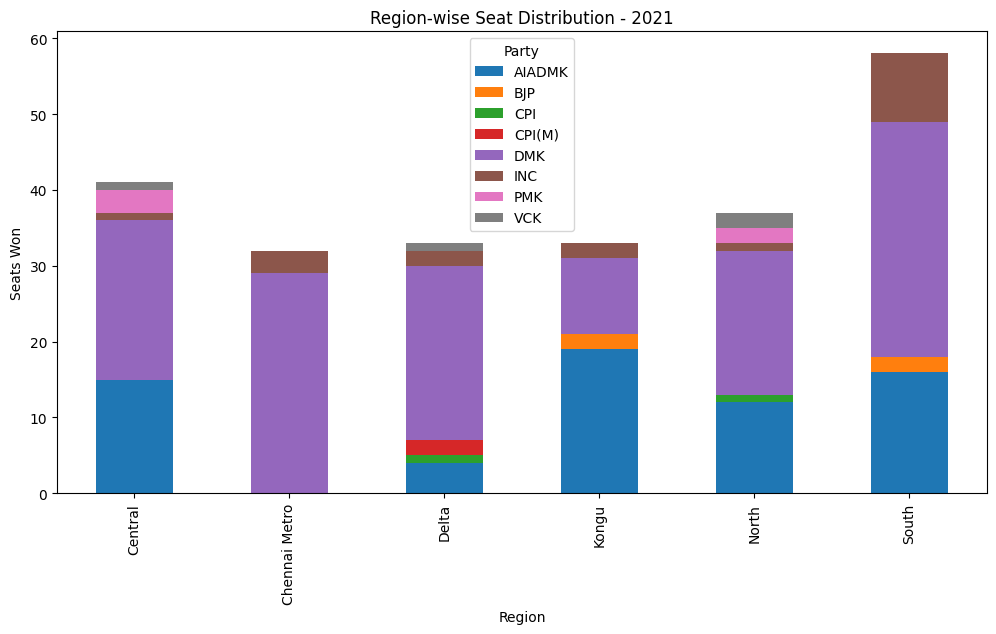

In [61]:
import matplotlib.pyplot as plt

pivot_2021.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Region-wise Seat Distribution - 2021")
plt.xlabel("Region")
plt.ylabel("Seats Won")
plt.legend(title="Party")
plt.show()

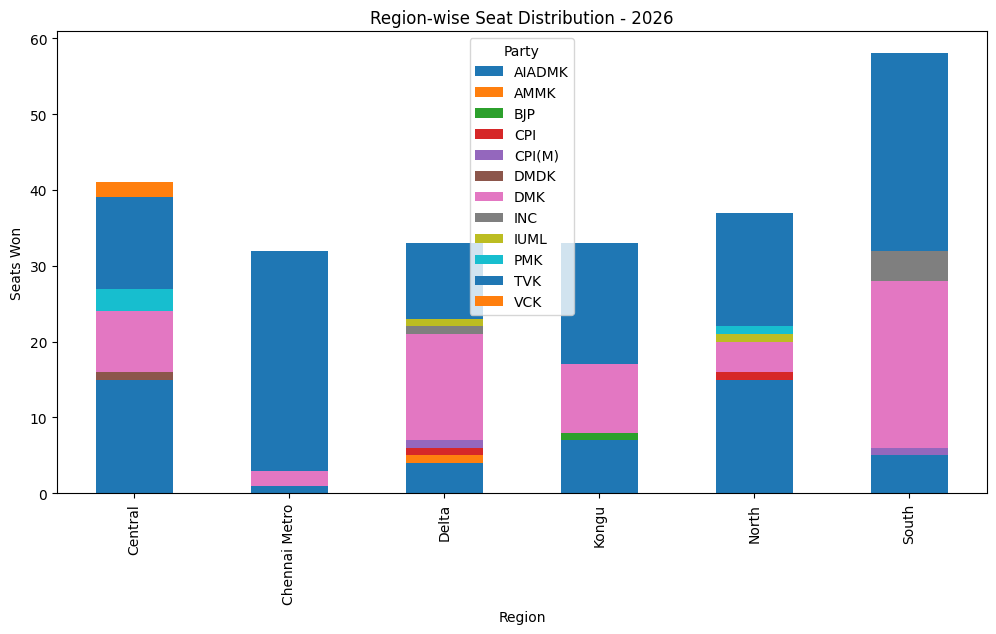

In [62]:
pivot_2026.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Region-wise Seat Distribution - 2026")
plt.xlabel("Region")
plt.ylabel("Seats Won")
plt.legend(title="Party")
plt.show()

## Key Observations

1. Chennai Metro experienced the sharpest political shift between 2021 and 2026.

2. TVK emerged as a major force across all six regions in 2026.

3. The 2026 election showed more fragmented regional outcomes compared to 2021.

4. DMK's regional dominance reduced in multiple regions including Chennai Metro, Central, and North.

5. AIADMK retained pockets of regional strength but with reduced overall dominance.

----

# Story 2 : Constituency Flip Analysis

This section analyzes constituencies that changed winning parties between 2021 and 2026 to identify patterns of political transition across Tamil Nadu.

In [63]:
flip_2021 = winner_table_2021[[
    'ac_number',
    'constituency',
    'winner_party',
    'region'
]]

In [64]:
flip_2026 = winner_table_2026[[
    'ac_number',
    'winner_party'
]]

In [65]:
flip_2021 = flip_2021.rename(columns={
    'winner_party': 'party_2021'
})

flip_2026 = flip_2026.rename(columns={
    'winner_party': 'party_2026'
})

In [66]:
flip_analysis = flip_2021.merge(
    flip_2026,
    on='ac_number'
)

In [67]:
flip_analysis['flipped'] = (
    flip_analysis['party_2021']
    != flip_analysis['party_2026']
)

In [68]:
flip_analysis['flipped'].value_counts()

flipped
True     163
False     71
Name: count, dtype: int64

In [69]:
flipped_constituencies = flip_analysis[
    flip_analysis['flipped'] == True
]

In [70]:
flipped_constituencies.head(20)

,ac_number,constituency,party_2021,region,party_2026,flipped
0,1,Gummidipundi,DMK,Chennai Metro,TVK,True
1,2,Ponneri,INC,Chennai Metro,TVK,True
2,3,Tiruttani,DMK,Chennai Metro,AIADMK,True
3,4,Thiruvallur,DMK,Chennai Metro,TVK,True
4,5,Poonamallee,DMK,Chennai Metro,TVK,True
5,6,Avadi,DMK,Chennai Metro,TVK,True
6,7,Maduravoyal,DMK,Chennai Metro,TVK,True
7,8,Ambattur,DMK,Chennai Metro,TVK,True
8,9,Madavaram,DMK,Chennai Metro,TVK,True
9,10,Thiruvottiyur,DMK,Chennai Metro,TVK,True


In [71]:
flip_patterns = (
    flipped_constituencies
    .groupby(['party_2021', 'party_2026'])
    .size()
    .reset_index(name='count')
)

In [72]:
flip_patterns.sort_values(
    by='count',
    ascending=False
)

,party_2021,party_2026,count
13,DMK,TVK,65
3,AIADMK,TVK,26
8,DMK,AIADMK,22
0,AIADMK,DMK,15
17,INC,TVK,11
12,DMK,PMK,3
5,BJP,DMK,2
18,PMK,AIADMK,2
19,PMK,TVK,2
6,BJP,TVK,2


In [73]:
# Regional Flip Analysis
region_flip_counts = (
    flipped_constituencies
    .groupby('region')
    .size()
    .reset_index(name='flip_count')
)

In [74]:
region_flip_counts.sort_values(
    by='flip_count',
    ascending=False
)

,region,flip_count
5,South,38
1,Chennai Metro,30
4,North,27
3,Kongu,27
0,Central,26
2,Delta,15


<Axes: title={'center': 'Constituency Flips by Region'}, xlabel='region'>

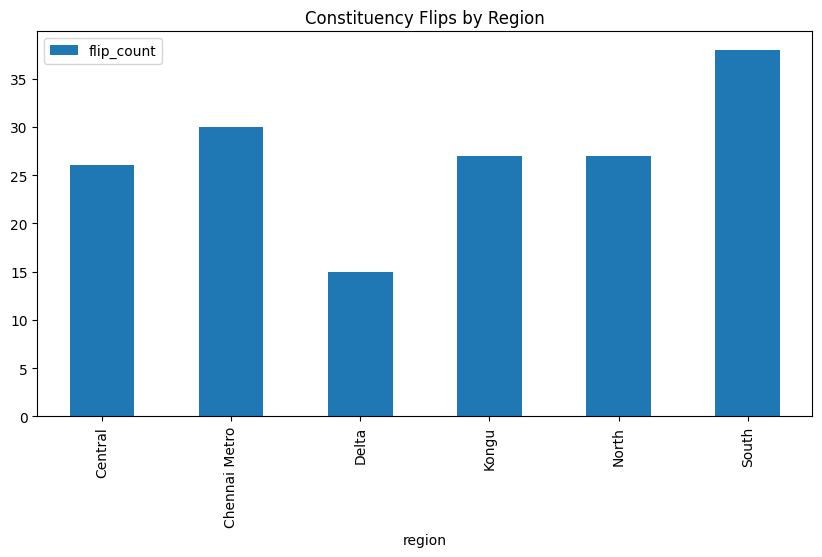

In [75]:
region_flip_counts.plot(
    x='region',
    y='flip_count',
    kind='bar',
    figsize=(10,5),
    title='Constituency Flips by Region'
)

## Key Observations

1. TVK emerged as the largest beneficiary of constituency-level flips in 2026.

2. The largest transition pattern observed was DMK → TVK, accounting for 65 flipped constituencies.

3. Chennai Metro experienced widespread constituency-level realignment.

4. South Tamil Nadu recorded the highest number of flipped constituencies.

5. Delta region remained comparatively stable relative to other regions.

-----

# Story 3 : Margin of Victory Analysis

This section compares constituency-level victory margins between 2021 and 2026 to understand changes in electoral competitiveness across Tamil Nadu.

In [76]:
import plotly.graph_objects as go


In [77]:
top_flips = flip_patterns[
    flip_patterns['count'] >= 5
]

In [78]:
labels = list(
    pd.concat([
        top_flips['party_2021'],
        top_flips['party_2026']
    ]).unique()
)

In [79]:
source = top_flips['party_2021'].apply(
    lambda x: labels.index(x)
)

target = top_flips['party_2026'].apply(
    lambda x: labels.index(x)
)

value = top_flips['count']

In [80]:
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title_text="Major Constituency Party Transitions (2021 → 2026)",
    font_size=12
)

fig.show()

In [81]:
winner_table_2021['margin'].mean()

np.float64(22870.547008547008)

In [82]:
winner_table_2026['margin'].mean()

np.float64(16784.24358974359)

<Axes: title={'center': 'Margin Distribution - 2021'}, ylabel='Frequency'>

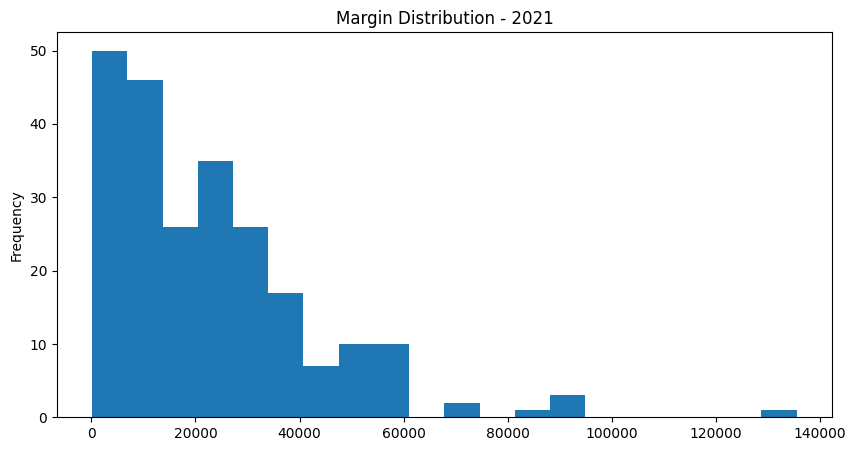

In [83]:
winner_table_2021['margin'].plot(
    kind='hist',
    bins=20,
    figsize=(10,5),
    title='Margin Distribution - 2021'
)

<Axes: title={'center': 'Margin Distribution - 2026'}, ylabel='Frequency'>

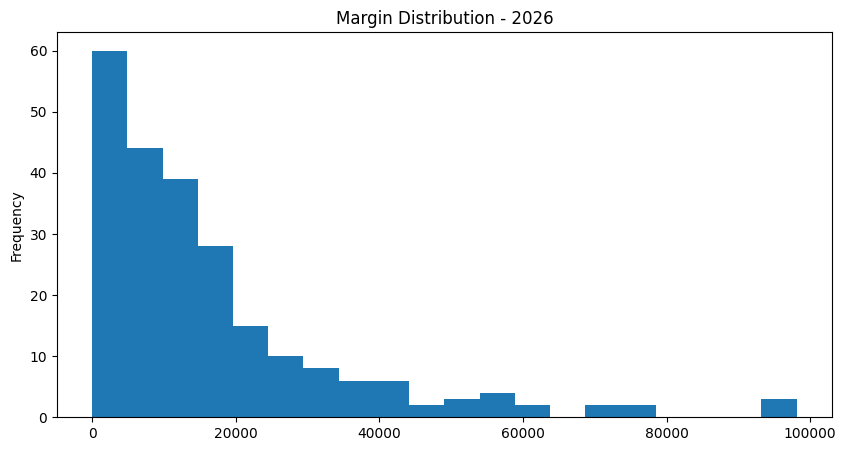

In [84]:
winner_table_2026['margin'].plot(
    kind='hist',
    bins=20,
    figsize=(10,5),
    title='Margin Distribution - 2026'
)

In [85]:
winner_table_2026.sort_values(
    by='margin'
).head(10)

,ac_number,constituency,winner_candidate,winner_party,winner_votes,turnout,reserved,region,runnerup_candidate,runnerup_party,runnerup_votes,margin,total_votes,winner_vote_share
184,185,Tiruppattur,SEENIVASA SETHUPATHY. R,TVK,83375,NaN,GEN,South,PERIAKARUPPAN. KR,DMK,83374,1,215710,38.651430
53,54,Veppanahalli,SRINIVASAN.P.S,DMK,74691,NaN,GEN,North,MUNUSAMY.K.P,AIADMK,74553,138,222608,33.552703
228,229,Kanniyakumari,THALAVAI SUNDARAM. N,AIADMK,75045,NaN,GEN,South,MAHESH.R,DMK,74831,214,239150,31.379887
65,66,Polur,ABISHEK. R,TVK,67961,NaN,GEN,North,SARAVANAN. P,DMDK,67734,227,211743,32.095984
75,76,Tirukkoyilur,PALANISAMY S,AIADMK,73033,NaN,GEN,Central,VIJAY R BARANIBALAAJI,TVK,72748,285,217318,33.606512
94,95,Paramathi-Velur,SEKAR S,AIADMK,61349,NaN,GEN,Central,MOORTHIY K S,DMK,61041,308,188845,32.486431
136,137,Kulithalai,SURIYANUR. A. CHANDRAN,DMK,68138,NaN,GEN,Kongu,G.BALASUBRAMANI,TVK,67559,579,209091,32.587725
170,171,Kumbakonam,VINOTH,TVK,78650,NaN,GEN,Delta,ANBALAGAN G,DMK,77971,679,208288,37.760217
126,127,Palani,RAVIMANOHARAN. K,AIADMK,66986,NaN,GEN,South,DR. PRAVEEN KUMAR. M,TVK,66293,693,208619,32.109252
71,72,Tindivanam,VANNI ARASU,VCK,63833,NaN,SC,Central,ARJUNAN. P,AIADMK,63099,734,196026,32.563537


In [86]:
winner_table_2026.sort_values(
    by='margin',
    ascending=False
).head(10)

,ac_number,constituency,winner_candidate,winner_party,winner_votes,turnout,reserved,region,runnerup_candidate,runnerup_party,runnerup_votes,margin,total_votes,winner_vote_share
85,86,Edappadi,EDAPPADI PALANISWAMI. K,AIADMK,148933,NaN,GEN,Central,PREMKUMAR. K,IND,50823,98110,258263,57.667184
26,27,Shozhinganallur,ECR P SARAVANAN,TVK,220382,NaN,GEN,Chennai Metro,S. ARAVIND RAMESH,DMK,123602,96780,447295,49.269945
8,9,Madavaram,M.L.VIJAYPRABHU,TVK,190462,NaN,GEN,Chennai Metro,S.SUDHARSANAM,DMK,95477,94985,361998,52.614103
5,6,Avadi,R.RAMESH KUMAR,TVK,180384,NaN,GEN,Chennai Metro,S.M.NASAR,DMK,104073,76311,346005,52.133351
87,88,Salem (West),LAKSHMANAN.S,TVK,120407,NaN,GEN,Central,KARTHE.M,PMK,45540,74867,234407,51.366640
4,5,Poonamallee,PRAKASAM.R,TVK,161309,NaN,SC,Chennai Metro,KRISHNASWAMY.A,DMK,88569,72740,308894,52.221474
112,113,Tiruppur (North),V.SATHYABAMA,TVK,131401,NaN,GEN,Kongu,M.S.M.ANANDAN,AIADMK,61409,69992,263457,49.875691
178,179,Viralimalai,VIJAYABASKAR. C,AIADMK,105773,NaN,GEN,Delta,MURUGESAN. P,TVK,43700,62073,203921,51.869597
6,7,Maduravoyal,RHEVANTH CHARAN,TVK,141725,NaN,GEN,Chennai Metro,GANAPATHY. K,DMK,80216,61509,293692,48.256337
7,8,Ambattur,BALAMURUGAN.G,TVK,133339,NaN,GEN,Chennai Metro,DR A.P. POORNIMA,DMK,74558,58781,259986,51.286992


## Key Observations

1. The average victory margin declined from approximately 22.8K votes in 2021 to 16.7K votes in 2026.

2. The 2026 election showed a larger concentration of close contests.

3. Several constituencies were decided by extremely narrow margins, including a one-vote victory in Tiruppattur.

4. Despite overall narrower margins, some constituencies still recorded very large landslide victories.

-----

In [91]:
winner_table_2021.to_csv("dashboard_data/winner_table_2021.csv", index=False)

winner_table_2026.to_csv("dashboard_data/winner_table_2026.csv", index=False)

flip_analysis.to_csv("dashboard_data/flip_analysis.csv", index=False)

flip_patterns.to_csv("dashboard_data/flip_patterns.csv", index=False)

region_flip_counts.to_csv("dashboard_data/region_flip_counts.csv", index=False)

# Conclusion

The 2026 Tamil Nadu Assembly election showed major regional redistribution, widespread constituency-level transitions, and narrower victory margins compared to 2021.

TVK emerged as a significant force across multiple regions, while several constituencies experienced major party realignments.

The election also demonstrated increased competitiveness, reflected in reduced average victory margins and several razor-thin contests.